# Session 0: Setup Sanity Check

Welcome to the EHR Patient Monitoring project! Before we dive into the conceptual exercises and hands-on work, let's make sure everything is set up correctly.

---

## What This Notebook Does

1. **Copy data from drive** - Copy the data shared with you and make sure it is ready
1. **Verify Python environment** — Check that required libraries are installed
2. **Load all data tables** — Confirm data files are accessible
3. **Display dataset features** — See what columns are available in each table

If this notebook runs without errors, you're ready to proceed!

## Setting Environment Up for Colab

Mount Google Drive.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

## Create Shortcut

Make sure you've already added a shortcut to the shared data folder. If you haven't already, follow the instructions below

1. Find the path to the folder we shared with you in your "Shared with me" Tab in drive

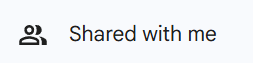

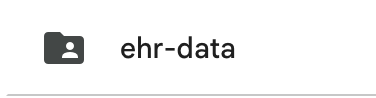

2. Right click the folder, and from the Organize tab select Add shortcut

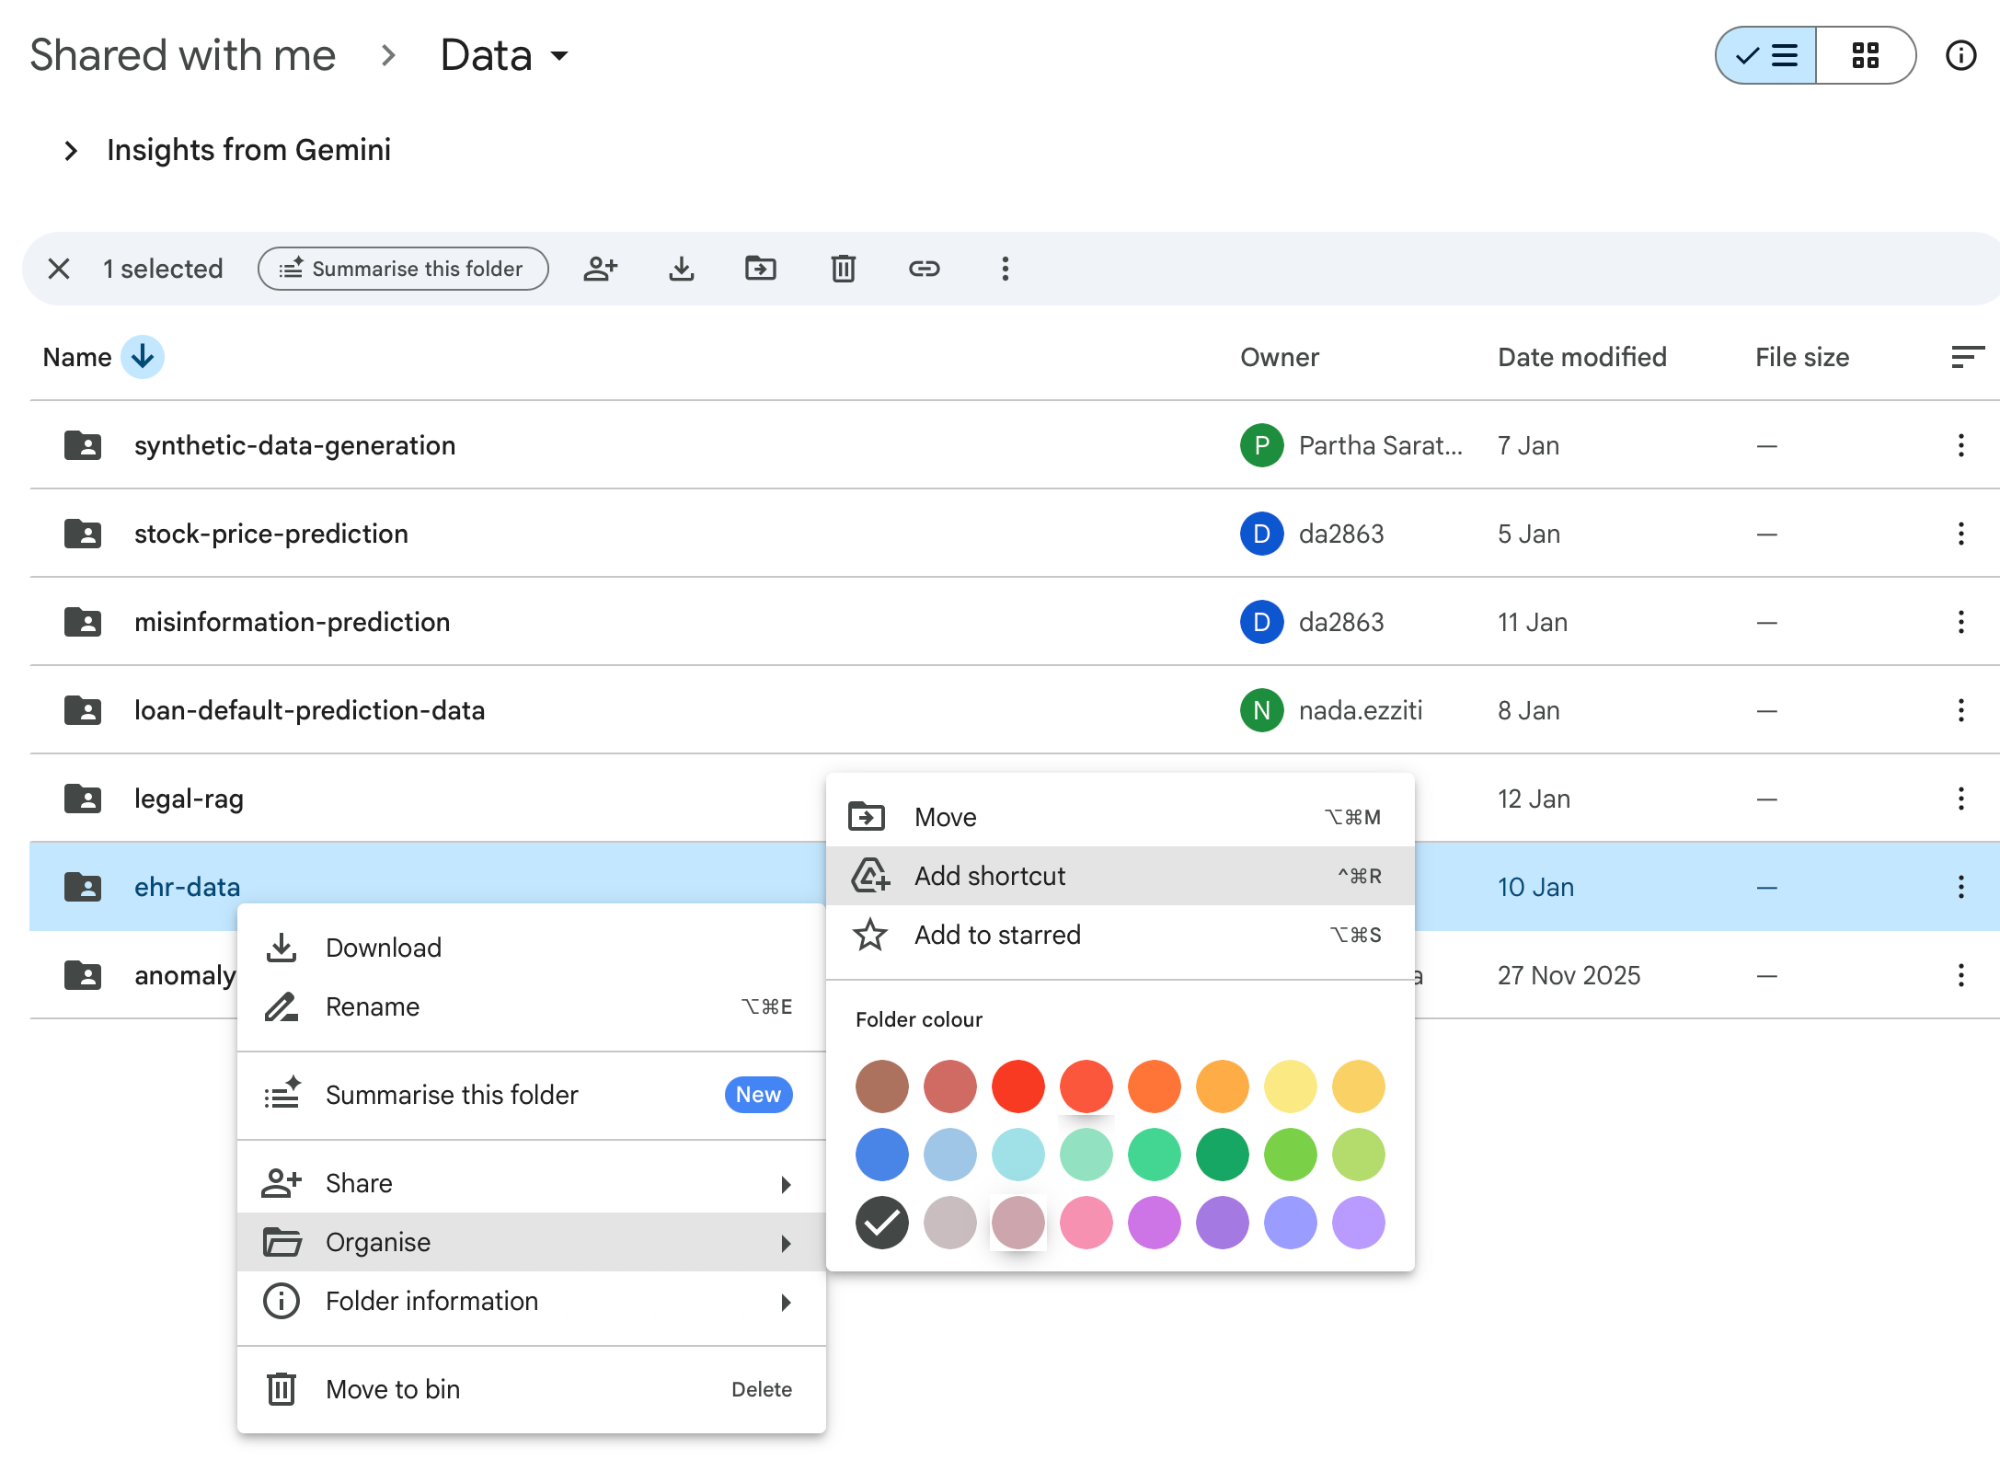

3. Find whatever location in your drive you want to store this path.

In [ ]:
# Same as the path you just saved into
shortcut_path = "/content/drive/MyDrive/<ADJUST THIS PATH>"

In [ ]:
!ls {shortcut_path}

## Copy the data

We're gonna copy the data into your own local folder. This could be in a shared folder with the rest of your team, or just your own. If it's a shared folder, you need to have editing permissions, and you need to set up a shortcut to the shared folder in your drive similar to how we did it above

In [ ]:
# This path is where you store the data.
# We will set up the shortcut to it later so you won't need to worry about it.
# My advice is to create it at "/content/drive/MyDrive/MASAID/AI_PROJECT_COURSE_DATA/EHR"
destination_path = "/content/drive/MyDrive/<ADJUST THIS PATH>"
!mkdir -p {destination_path}

In [ ]:
!cp -R {shortcut_path}/* {destination_path}

Check that copying was a success

In [ ]:
!ls -R {destination_path}

## Add shortcut

Finally, now we're going to add a shortcut from where you want to store your data to the expected relative path for this cloned github repo. For this project, that would be at `/data` relative to the root of the repo. Make sure you store the shortcut at `repo_path/` (ask your TA if that is unclear).

Make sure to name this folder `data` ,

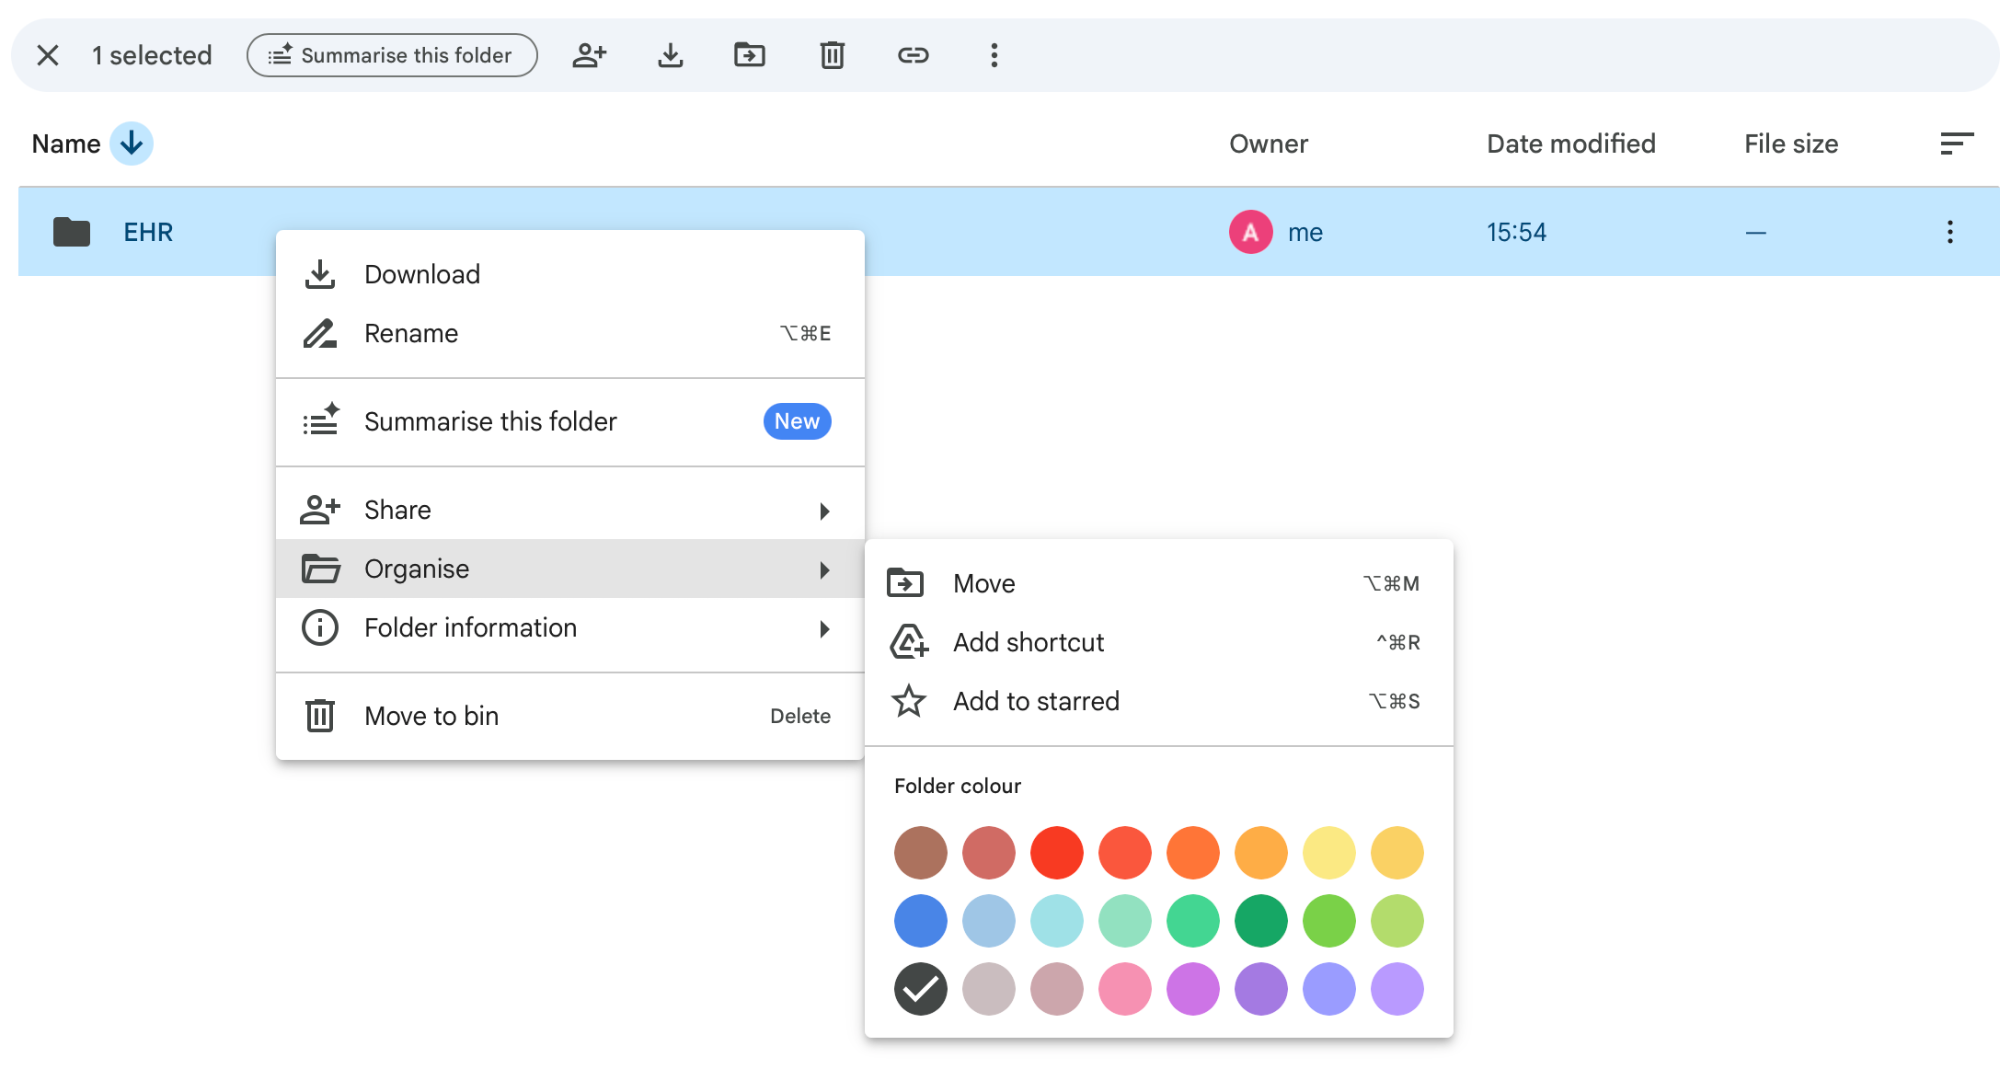

Now let's set the paths:

In [ ]:
# Set your Google Drive path here
# Replace <PATH_TO_REPO> with your actual repository path
REPO_PATH = "/content/drive/MyDrive/<PATH_TO_REPO>"

# Data directory for Week 1 session 0
DATA_DIR = f"{REPO_PATH}/data/EHR/ehr-data"

print(f"Repository path: {REPO_PATH}")
print(f"Data directory: {DATA_DIR}")

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import os

print("Core libraries imported successfully")
print(f"   pandas version: {pd.__version__}")
print(f"   numpy version:  {np.__version__}")

## Load Dataset

In [ ]:
# Verify the directory exists
if os.path.exists(DATA_DIR):
    print(f"Data directory found: {DATA_DIR}")
else:
    print(f"ERROR: Data directory not found at {DATA_DIR}")
    print("   Please check that PATH is set correctly above.")

In [ ]:
# Load all 7 tables
patients = pd.read_csv(os.path.join(DATA_DIR, "csv/patients.csv"))
encounters = pd.read_csv(os.path.join(DATA_DIR, "csv/encounters.csv"))
conditions = pd.read_csv(os.path.join(DATA_DIR, "csv/conditions.csv"))
medications = pd.read_csv(os.path.join(DATA_DIR, "csv/medications.csv"))
observations = pd.read_csv(os.path.join(DATA_DIR, "csv/observations.csv"))
procedures = pd.read_csv(os.path.join(DATA_DIR, "csv/procedures.csv"))
allergies = pd.read_csv(os.path.join(DATA_DIR, "csv/allergies.csv"))

print("All 7 tables loaded successfully!")

In [ ]:
tables = {
    'patients': patients,
    'encounters': encounters,
    'conditions': conditions,
    'medications': medications,
    'observations': observations,
    'procedures': procedures,
    'allergies': allergies
}

print("DATASET OVERVIEW")
print("=" * 50)
for name, df in tables.items():
    print(f"{name:15} {len(df):>10,} rows  x  {len(df.columns):>2} columns")
print("=" * 50)
print(f"{'TOTAL':15} {sum(len(df) for df in tables.values()):>10,} rows")

In [ ]:
print("AVAILABLE FEATURES BY TABLE")
print("=" * 70)

for name, df in tables.items():
    print(f"\n{name.upper()}")
    print(f"   Columns: {list(df.columns)}")

In [ ]:
print("ENCOUNTERS (first 3 rows)")
display(encounters.head(3))

In [ ]:
print("CONDITIONS (first 3 rows)")
display(conditions.head(3))

In [ ]:
print("MEDICATIONS (first 3 rows)")
display(medications.head(3))

In [ ]:
print("OBSERVATIONS (first 3 rows)")
display(observations.head(3))

In [ ]:
print("PROCEDURES (first 3 rows)")
display(procedures.head(3))

---

## Setup Complete!

If you made it here without errors, your environment is ready.

### Quick Reference: Key Columns

| Table | Key Columns |
|-------|-------------|
| **patients** | ID, BIRTHDATE, GENDER, RACE |
| **encounters** | ID, DATE, PATIENT, DESCRIPTION |
| **conditions** | PATIENT, ENCOUNTER, CODE, DESCRIPTION |
| **medications** | PATIENT, ENCOUNTER, DESCRIPTION, START, STOP |
| **observations** | PATIENT, ENCOUNTER, CODE, VALUE, UNITS |
| **procedures** | PATIENT, ENCOUNTER, DATE, DESCRIPTION |
| **allergies** | PATIENT, DESCRIPTION |

### Important Relationships

- **PATIENT** column links all tables back to `patients.ID`
- **ENCOUNTER** column links clinical events to specific visits in `encounters.ID`

---

**You're ready to proceed to the conceptual exercises and Session 3!**